CICIDS Loaded: (2313810, 78)
Training Data Prepared: (2313810, 7)
NS3 Test Dataset Loaded: (694143, 7)

Model Trained (CICIDS Train → NS3 Test)

===== SAMPLE OUTPUT (15 rows, random mix, all classes) =====
    Prediction                                  Strategy
0            4  SECURE NETWORK (CYBER ESPIONAGE DEFENSE)
1            4  SECURE NETWORK (CYBER ESPIONAGE DEFENSE)
2            1                         BLOCK DATA MINING
3            0                          NO ACTION (SAFE)
4            1                         BLOCK DATA MINING
5            0                          NO ACTION (SAFE)
6            1                         BLOCK DATA MINING
7            2   ENCRYPT CHANNEL (EAVESDROPPING DEFENSE)
8            0                          NO ACTION (SAFE)
9            4  SECURE NETWORK (CYBER ESPIONAGE DEFENSE)
10           3        RANDOMIZE ROUTE (TRACKING DEFENSE)
11           2   ENCRYPT CHANNEL (EAVESDROPPING DEFENSE)
12           3        RANDOMIZE ROUTE (TRACKING DEFEN

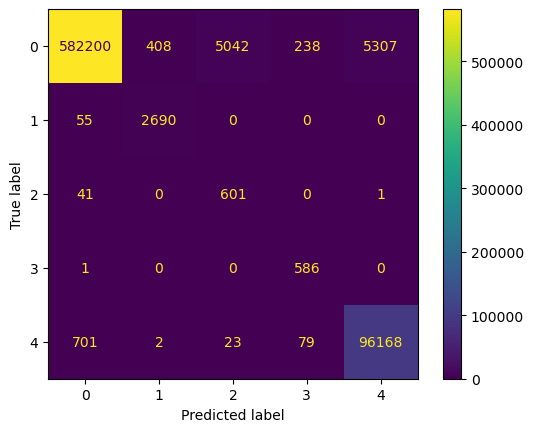

In [8]:
# ================== main_project.py ==================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)

# ================== LOAD TRAINING DATA (CICIDS) ==================
files = [
    "Benign-Monday-no-metadata.parquet",
    "Bruteforce-Tuesday-no-metadata.parquet",
    "DDoS-Friday-no-metadata.parquet",
    "DoS-Wednesday-no-metadata.parquet",
    "Infiltration-Thursday-no-metadata.parquet",
    "Portscan-Friday-no-metadata.parquet",
    "WebAttacks-Thursday-no-metadata.parquet",
    "Botnet-Friday-no-metadata.parquet"
]

dfs = [pd.read_parquet(f) for f in files]
cicids = pd.concat(dfs, ignore_index=True)
print("CICIDS Loaded:", cicids.shape)

# ================== ATTACK LABEL MAPPING ==================
# 0 = Normal
# 1 = Data Mining
# 2 = Eavesdropping
# 3 = Tracking
# 4 = Cyber Espionage
def map_attack(label):
    label = str(label).lower()

    if "benign" in label:
        return 0
    if ("ftp-patator" in label) or ("ssh-patator" in label) or ("bruteforce" in label):
        return 1
    if "web" in label:
        return 2
    if "portscan" in label:
        return 3
    if "infiltration" in label or "bot" in label:
        return 4
    return 4

cicids["AttackLabel"] = cicids["Label"].apply(map_attack)

# ================== FEATURE EXTRACTION ==================
df = pd.DataFrame()
df["packet_size"] = cicids["Avg Packet Size"]
df["delay"] = cicids["Flow Duration"]
df["protocol"] = cicids["Protocol"]
df["fwd_packets"] = cicids["Total Fwd Packets"]
df["bwd_packets"] = cicids["Total Backward Packets"]
df["bytes_per_sec"] = cicids["Flow Bytes/s"]
df["AttackLabel"] = cicids["AttackLabel"]

# Clean NaN / inf
df = df.replace([np.inf, -np.inf], np.nan).dropna()
print("Training Data Prepared:", df.shape)

# ================== LOAD NS3 TEST DATASET (CSV) ==================
# This file is created using: generate_ns3_dataset.py
ns3_df = pd.read_csv("ns3_test_dataset.csv")
print("NS3 Test Dataset Loaded:", ns3_df.shape)

# ================== FEATURES ==================
features = [
    "packet_size",
    "delay",
    "protocol",
    "fwd_packets",
    "bwd_packets",
    "bytes_per_sec"
]

# ================== BALANCE TRAIN DATA ==================
balanced_parts = []

for cls in sorted(df["AttackLabel"].unique()):
    class_data = df[df["AttackLabel"] == cls]

    if len(class_data) > 0:
        if cls == 0:
            sample_size = min(12000, len(class_data))
        else:
            sample_size = min(15000, len(class_data))

        balanced_parts.append(class_data.sample(n=sample_size, random_state=42))

train_df_balanced = pd.concat(balanced_parts, ignore_index=True)

X_train = train_df_balanced[features]
y_train = train_df_balanced["AttackLabel"]

# ================== TEST DATA ==================
X_test = ns3_df[features]
y_test = ns3_df["AttackLabel"]

# ================== SCALING ==================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ================== MODEL TRAINING ==================
model = RandomForestClassifier(
    n_estimators=250,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)
print("\nModel Trained (CICIDS Train → NS3 Test)")

# ================== PREDICTION ==================
predictions = model.predict(X_test_scaled)

# ================== GAME THEORY STRATEGIES ==================
def game_strategy(action):
    if action == 0:
        return "NO ACTION (SAFE)"
    elif action == 1:
        return "BLOCK DATA MINING"
    elif action == 2:
        return "ENCRYPT CHANNEL (EAVESDROPPING DEFENSE)"
    elif action == 3:
        return "RANDOMIZE ROUTE (TRACKING DEFENSE)"
    elif action == 4:
        return "SECURE NETWORK (CYBER ESPIONAGE DEFENSE)"
    return "UNKNOWN"

results_df = pd.DataFrame({
    "Prediction": predictions,
    "Strategy": [game_strategy(p) for p in predictions]
})

# ================== SAMPLE OUTPUT (15 ROWS, RANDOM, ALL CLASSES) ==================
print("\n===== SAMPLE OUTPUT (15 rows, random mix, all classes) =====")

sample_outputs = []
per_class = 3  # 3 x 5 = 15 rows

for cls in range(5):
    cls_rows = results_df[results_df["Prediction"] == cls]
    if len(cls_rows) > 0:
        take = min(per_class, len(cls_rows))
        sample_outputs.append(cls_rows.sample(take))

sample_out = pd.concat(sample_outputs).sample(frac=1).reset_index(drop=True)
print(sample_out)

# ================== RESULTS ==================
print("\n===== ACCURACY =====")
print(accuracy_score(y_test, predictions))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, predictions))

print("\n===== CONFUSION MATRIX =====")
print(confusion_matrix(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.show()